In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import scipy.io as io
import sys
from tqdm import tqdm
import numpy as np

global_path = "/home/ids/edabier/HSU"
# global_path = "/home/edabier/Documents/Thèse/benchmark"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils
from src.utils import plots
from src.models import models
from src.models import foundation_models as rsfm

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

Using device: cuda:0


In [39]:
dataset = "urban4"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
A_init = utils.oneD_to_2d(A_flat)
H = Y_init.shape[-1]
Y_init = Y_init.unsqueeze(0)
A = A_init.unsqueeze(0)

if dataset == "urban4":
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt"
else:
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

fm, Y_up, new_H = rsfm.create_fm("DOFA", Y_init, n_features=1, use_cls=False, extend_cls=False, path=global_path, patch_size=16)
features = rsfm.get_dofa_features(fm, Y_up, wavelengths)
D = int(features.shape[0]/1)
alpha = int(features.shape[1]**0.5)
unmixer = rsfm.Unmixing_from_features(D=D, alpha=alpha, B=B, c=c, n_features=1, use_cls=False)

In [40]:
def get_adjacent_crops(A_hats, shift):
    overlaps = []
    n_crops = len(A_hats)
    n_rows = n_cols = int(n_crops**0.5)
    H = W = A_hats[0].shape[-1]
    directions = [(0, 1), (1, 0), (1, 1), (1, -1)]
    for i in range(n_rows):
        for j in range(n_cols):
            k = i * n_rows + j  # index of current crop
            i_k = i * shift
            j_k = j * shift
            # Check all 4 possible adjacent crops
            for di, dj in directions:
                i_adj = i + di
                j_adj = j + dj
                if 0 <= i_adj < n_rows and 0 <= j_adj < n_cols:
                    l = i_adj * n_rows + j_adj  # index of adjacent crop
                    i_l = i_adj * shift
                    j_l = j_adj * shift
                    # Compute overlap
                    i_start = max(i_k, i_l)
                    i_end = min(i_k + H, i_l + H)
                    j_start = max(j_k, j_l)
                    j_end = min(j_k + W, j_l + W)
                    if i_end > i_start and j_end > j_start:
                        # Extract overlapping regions
                        overlap_k = A_hats[k][:, :, i_start - i_k:i_end - i_k, j_start - j_k:j_end - j_k]
                        overlap_l = A_hats[l][:, :, i_start - i_l:i_end - i_l, j_start - j_l:j_end - j_l]
                        overlaps.append((overlap_k, overlap_l))
    return overlaps

def consistency_loss(overlaps, similarity="mse"):
    total_loss = 0.0
    for overlap_k, overlap_l in overlaps:
        if similarity == "mse":
            loss = F.mse_loss(overlap_k, overlap_l)
        elif similarity == "cosine":
            loss = 1 - F.cosine_similarity(overlap_k, overlap_l).mean()
        else:
            raise ValueError("Similarity must be 'mse' or 'cosine'")
        total_loss += loss
    return total_loss

def instantiate_models(pad, shift, Y_init, D, alpha, new_H, B, c, dev):
    n_models = (2*(pad-(shift-1))+1)**2
    n_rows = 2*(pad-(shift-1))+1
    model_list = []
    optimizers = []
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=0.002, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9))
    for i in range(n_models):
        model = torch.compile(rsfm.Unmixing_from_features(D=D, alpha=alpha, H=new_H, B=B, c=c, n_features=1, use_cls=False, is_cnnaeu=False))
        model.apply(model.weights_init)

        x_i = (i//n_rows)
        y_i = (i%n_rows)*shift
        Y = Y_init[:, :, x_i:x_i+new_H, y_i:y_i+new_H]

        model = models.init_decoder_weights(model, Y/Y.max(), c, is_unmixer=True, normalize=False)
        model = model.to(dev)
        optimizer = build_optim_wrapper(model, optim_wrapper)

        model_list.append(model)
        optimizers.append(optimizer)
    return model_list, optimizers

In [41]:
pad = 8
shift = 8
n_rows = 2*(pad-(shift-1))+1

fm, Y_up, _ = rsfm.create_fm("DOFA", Y_init, n_features=1, use_cls=False, extend_cls=False, path=global_path, patch_size=16)
features = rsfm.get_dofa_features(fm, Y_up, wavelengths)
D = int(features.shape[0]/1)
alpha = int(features.shape[1]**0.5)

Y_padded = F.pad(Y_init, pad=(pad, pad, pad, pad), mode="reflect")
model_list, optimizers = instantiate_models(pad, shift, Y_padded, D, alpha, H, B, c, dev)


{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14


In [42]:
epochs=200
total_loss = 0
A_hats = []

for epoch in range(epochs):

    total_loss = 0
    A_hats = []


    for i in range(0, 2*pad + 1, shift):
        for j in range(0, 2*pad + 1, shift):

            i_model = n_rows*(i//shift) + j//shift
            # print(f"Forwarding model {i_model}")

            model = model_list[i_model]
            optimizer = optimizers[i_model]
            optimizer.zero_grad()

            Y_crop = Y_padded[:, :, i:i+H, j:j+H]
            Y_crop = Y_crop.to(dev)

            _, features = rsfm.extract_f(fm, Y_crop, H, wavelengths, use_cls=False)
            E_hat, A_hat, Y_hat = model(features)
            A_hats.append(A_hat)
            
            loss = model.loss(Y_crop, Y_hat, A_hat, E_hat)
            total_loss += loss
    
    # overlaps = get_adjacent_crops(A_hats, shift)
    # consistency = consistency_loss(overlaps)

    # total_loss += consistency
    total_loss.backward()

    for i_model, model in enumerate(model_list):
        optimizer = optimizers[i_model]    
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
        optimizer.step()

        with torch.no_grad():
            constraints = models.weightConstraint()
            model.decoder.apply(constraints)
    
    if epoch%(epochs//10)==0:
        print(f"Current epoch: {epoch}")

Current epoch: 0
Current epoch: 20
Current epoch: 40
Current epoch: 60
Current epoch: 80
Current epoch: 100
Current epoch: 120
Current epoch: 140
Current epoch: 160
Current epoch: 180


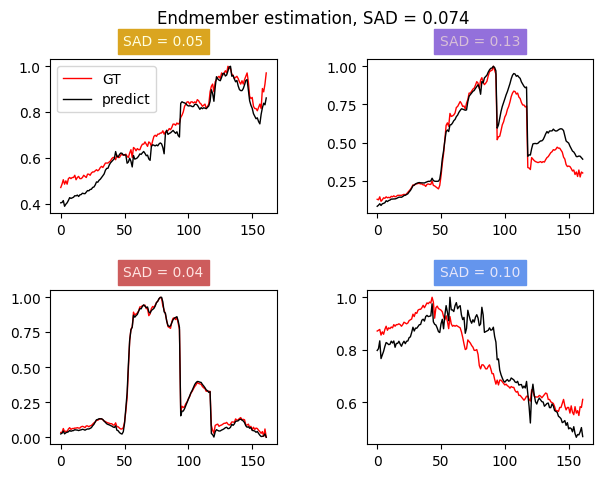

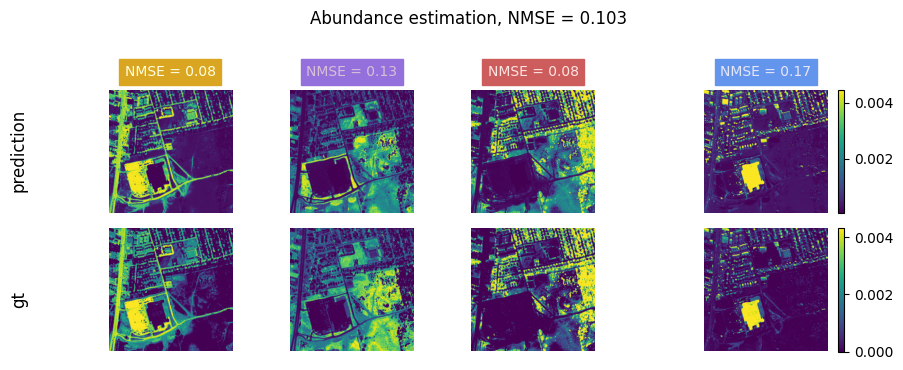

In [43]:
A_hat_padded = torch.zeros(1, c, H+2*pad,H+2*pad)
weights = torch.zeros_like(A_hat_padded)
E_hats = torch.zeros((2*pad+1)**2, B, c)

for i in range(0, 2*pad + 1, shift):
    for j in range(0, 2*pad + 1, shift):

        i_model = n_rows*(i//shift) + j//shift
        model = model_list[i_model]
        optimizer = optimizers[i_model]
        optimizer.zero_grad()

        model.eval()
        with torch.no_grad():

            Y_crop = Y_padded[:, :, i:i+H, j:j+H]
            _, features = rsfm.extract_f(fm, Y_crop, H, wavelengths, use_cls=False)
            E_hat, A_hat, _ = model(features)

            E_hats[i+j] = E_hat
            A_hat_padded[:, :, i:i+H, j:j+H] += A_hat
            weights[:, :, i:i+H, j:j+H] += 1

A_hat_padded /= weights
E_hat_m = torch.mean(E_hats, dim=0)    
sad_pad, _, mse_pad = plots.compute_metrics_and_plot(E_hat_m, A_hat_padded[:,:,pad*2:-1-2*pad, pad*2:-1-2*pad], A_init[:,pad:-1-pad, pad:-1-pad], E_init, normalize_E=True, normalize_A=True, return_results=True)#, plot_A=False, plot_E=False)

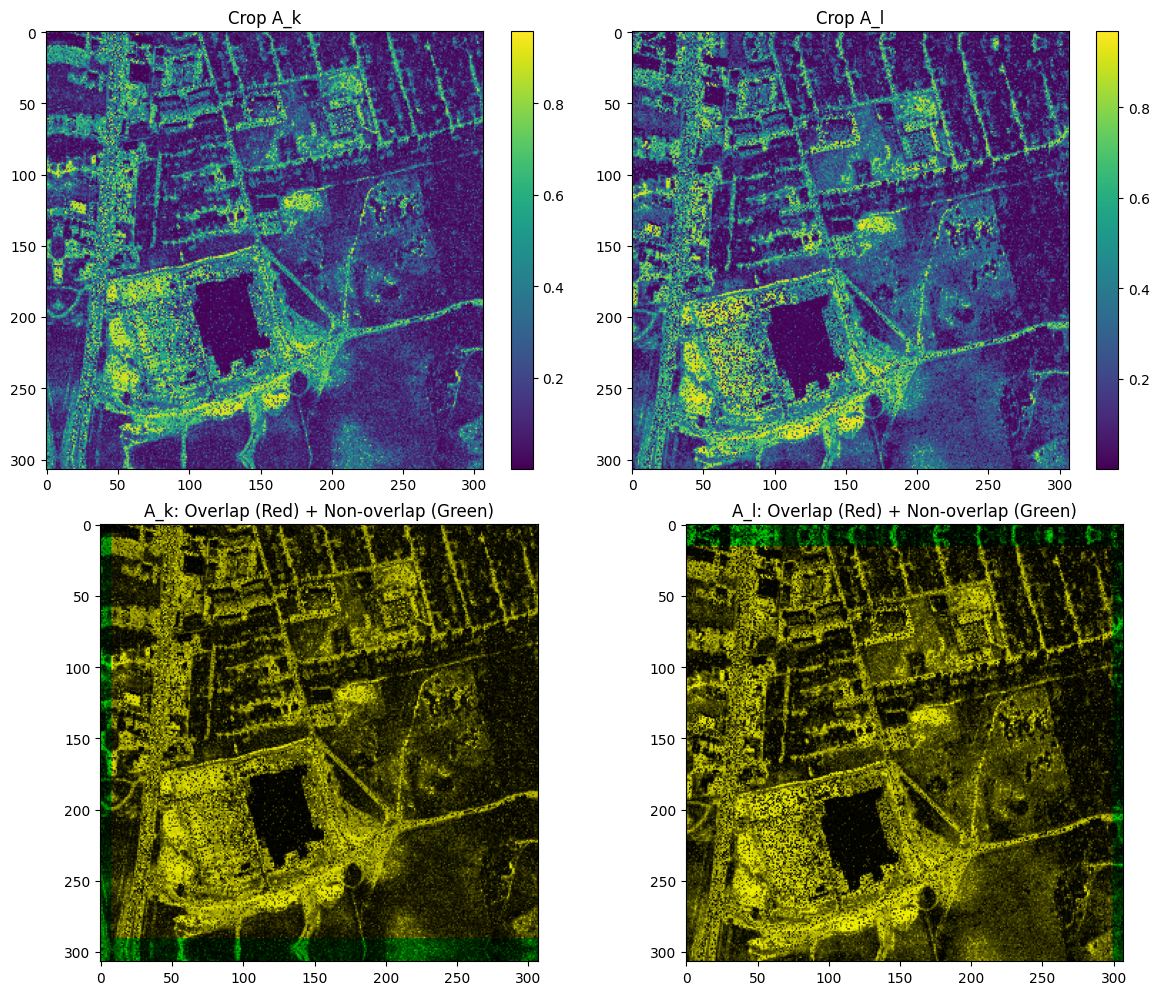

In [9]:
def plot_overlap(k,l, A_hats):
    A_k = A_hats[k][0,0]
    A_l = A_hats[l][0,0]

    # Get the top-left corners of the two crops in the padded image
    i_k = (k // int(len(A_hats)**0.5)) * shift
    j_k = (k % int(len(A_hats)**0.5)) * shift
    i_l = (l // int(len(A_hats)**0.5)) * shift
    j_l = (l % int(len(A_hats)**0.5)) * shift

    # Compute overlap
    i_start = max(i_k, i_l)
    i_end = min(i_k + H, i_l + H)
    j_start = max(j_k, j_l)
    j_end = min(j_k + H, j_l + H)

    # Extract overlapping regions
    overlap_k = A_k[i_start - i_k:i_end - i_k, j_start - j_k:j_end - j_k]
    overlap_l = A_l[i_start - i_l:i_end - i_l, j_start - j_l:j_end - j_l]

    # Convert tensors to numpy arrays
    A_k_np = A_k.detach().cpu().numpy()
    A_l_np = A_l.detach().cpu().numpy()
    overlap_k_np = overlap_k.detach().cpu().numpy()
    overlap_l_np = overlap_l.detach().cpu().numpy()

    # Get shapes
    h, w = overlap_k_np.shape

    # Create a figure with 2 rows and 2 columns
    fig, ax = plt.subplots(2, 2, figsize=(12, 10))

    # Plot A_k
    im_k = ax[0, 0].imshow(A_k_np, cmap='viridis')
    ax[0, 0].set_title(f'Crop A_k')
    fig.colorbar(im_k, ax=ax[0, 0])

    # Plot A_l
    im_l = ax[0, 1].imshow(A_l_np, cmap='viridis')
    ax[0, 1].set_title(f'Crop A_l')
    fig.colorbar(im_l, ax=ax[0, 1])

    # Create a combined visualization for A_k with overlap highlighted
    A_k_colored = np.zeros((H, H, 3))
    A_k_colored[..., 1] = A_k_np  # Green channel for non-overlap
    A_k_colored[i_start - i_k:i_end - i_k, j_start - j_k:j_end - j_k, 0] = overlap_k_np  # Red channel for overlap
    ax[1, 0].imshow(A_k_colored)
    ax[1, 0].set_title('A_k: Overlap (Red) + Non-overlap (Green)')

    # Create a combined visualization for A_l with overlap highlighted
    A_l_colored = np.zeros((H, H, 3))
    A_l_colored[..., 1] = A_l_np  # Green channel for non-overlap
    A_l_colored[i_start - i_l:i_end - i_l, j_start - j_l:j_end - j_l, 0] = overlap_l_np  # Red channel for overlap
    ax[1, 1].imshow(A_l_colored)
    ax[1, 1].set_title('A_l: Overlap (Red) + Non-overlap (Green)')

    plt.tight_layout()
    plt.show()

plot_overlap(6,1,A_hats)

In [ ]:
A_blank = torch.zeros(1, c, H+2*pad, H+2*pad)

for i in range(0, 2*pad + 1, shift):
    for j in range(0, 2*pad + 1, shift):

        i_model = n_rows*(i//shift) + j//shift

        A_print = torch.zeros_like(A_blank)
        A_print[:, :, i:i+H, j:j+H] = A_blank[:, :, i:i+H, j:j+H] + A_hats[i_model]
        plt.imshow(A_print[0,0].detach().cpu())
        plt.show()